# Integration
Integration is the inverse of differentiation 
$$f(x)=\frac{dF(x)}{dx}$$
and
$$F(x)=\int_{x_0}^x f(x)dx$$
It can be performed analytically, if the integrand is quite simple, or numerically, in the last case is called *quadrature*. The integrand in multiple integrals can be a multivariate function and the integration can be performed for each dimension. The limits of the integration intervals can be finite or infinite. Integral functions for which the unknown function is the integrand are another part of integration but they will not be discussed here. When the number of dimensions is high a better approach to calculate an integral is to use the **Monte Carlo** method. Integrals are also used to transform a function by computing its coefficients for a set of basis functions. The  examples in this notebook follow those from chapter 8 of the book by Johansson [*Numerical Python, 3rd Edition*](https://github.com/jrjohansson/numerical-python-book-code/blob/master/ch08-code-listing.ipynb). 

In [2]:
import numpy as np
from numpy import polynomial as P
import sympy
import scipy
from scipy import integrate
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.axes3d import Axes3D
print('NumPy version: {}'.format(np.__version__))
print('SymPy version: {}'.format(sympy.__version__))
print('SciPy version: {}'.format(scipy.__version__))
print('Matplotlib version: {}'.format(mpl.__version__))

NumPy version: 1.26.4
SymPy version: 1.14.0
SciPy version: 1.17.1
Matplotlib version: 3.8.4


## Methods of integration
An integral of an univariate function $f(x)$ between two points (a,b) can be interpreted as the area delimited by the function. The area is computed by discretizing the interval (a,b) in a number N of segments 
$$\Delta x = \frac{b-a}{N}$$ 
and calculating the sum
$$\int_a^b f(x)dx = \sum_{i=1}^N [f(x_i) \Delta x +r_N$$
where $f(x_i)$ is calculated at $x_i$, in the middle of each segment $\Delta x$, and $r_N$ is the residual, that is, the difference between the true value and the approximation. If N is large enough we can assume $r_N \approx 0$. Another approach is to approximate the function using a linear combination of polynomials or other basis functions that can be integrated analytically. Starting from
$$f(x) \approx \sum_{i=o}^n c_i \phi_i(x)$$
$$\int f(x)dx \approx \int (\sum_{i=o}^n c_i \phi_i(x))dx = \sum_{i=o}^n c_i \int \phi_i(x) dx$$
This equation represents a linear system that can be solved by evaluating the function $f(x)$ at n points.

## Numerical integration
We might want to integrate a function with its explicit definition or with a sample of data points. 

### Defined functions
We start with the first case. Let's say we want to integrate the function
$$f(x)= ae^{\frac{(x-b)^2}{c^2}}$$
for $x \in [-1,1]$. The [SciPy integrate](https://docs.scipy.org/doc/scipy/tutorial/integrate.html#general-integration-quad) module provides a method to numerically integrate univariate defined functions. This method is based on the Gaussian quadrature that uses polynomial basis functions.  

In [4]:
def f(x, a, b, c):
    return a * np.exp(-((x - b) / c)**2)

In [6]:
val, err = integrate.quad(f, -1, 1, args=(1, 2, 3))
val

1.2763068351022229

The same method can be used to integrate in the interval $(-\infty, + \infty)$

In [12]:
f = lambda x: np.exp(-x**2)

In [13]:
val, err = integrate.quad(f, -np.inf, np.inf)
val

1.7724538509055159

In [20]:
f = lambda x: 1 / np.sqrt(abs(x))

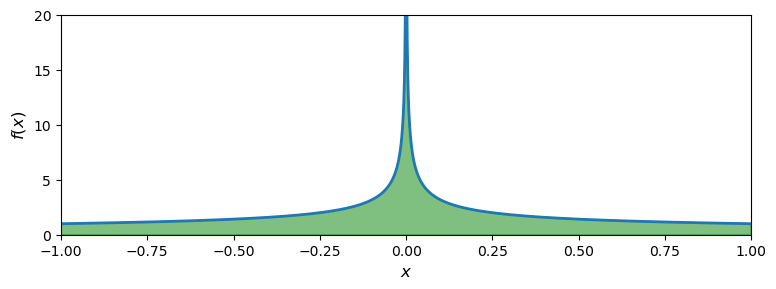

In [23]:
fig, ax = plt.subplots(figsize=(8, 3))

x = np.linspace(-1, 1, 10000)
ax.plot(x, f(x), lw=2)
ax.fill_between(x, f(x), color='green', alpha=0.5)
ax.set_xlabel("$x$", fontsize=12)
ax.set_ylabel("$f(x)$", fontsize=12)
ax.set_ylim(0, 20)
ax.set_xlim(-1, 1)

fig.tight_layout()

We remove the poin x=0.0 where the integrand is divergent

In [15]:
val, err = integrate.quad(f, -1, 1, points=[0.0])
val

1.4936482656248542

### Sampled functions
Often we do not have an explicit function as the integrand but a sample of observations, for example taken at regularly spaced points and at time intervals. In these cases the [Newton-Cotes](https://en.wikipedia.org/wiki/Newton%E2%80%93Cotes_formulas) method or one of its flavours is well suited for the integration task. As an example, we simulate a function from which we sample some data points.

In [4]:
f = lambda x: np.sqrt(x)
a, b = 0, 2
x = np.linspace(a, b, 25)
y = f(x)
y.shape

(25,)

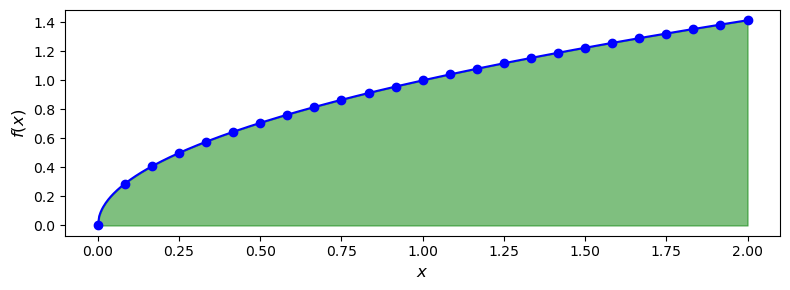

In [6]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(x, y, 'bo')
xx = np.linspace(a, b, 500)
ax.plot(xx, f(xx), 'b-')
ax.fill_between(xx, f(xx), color='green', alpha=0.5)
ax.set_xlabel(r"$x$", fontsize=12)
ax.set_ylabel(r"$f(x)$", fontsize=12)
fig.tight_layout()

We can use the trapezoid method to calculate the area of each interval between two data points or the Simpson method. The data point do not have to be evenly spaced. The 1st method use a line to approximate the function between the two data point of each segment. The Simpson method uses a 3rd degree polynomial.

In [8]:
val_trapz = integrate.trapezoid(y, x)
val_trapz

1.8808217160508505

In [9]:
val_simps = integrate.simpson(y, x)
val_simps

1.883665102448715

## Multiple integration